In [1]:
import pandas as pd
import numpy as np
import joblib

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
data_path = r"D:\SLIIT UNI\Y4S2\ML\assignment 01\dataset\heart_dataset\heart_disease_risk_dataset_earlymed.csv"

df = pd.read_csv(data_path)

print("Dataset Shape:", df.shape)
df.head()

Dataset Shape: (70000, 19)


,Chest_Pain,Shortness_of_Breath,Fatigue,Palpitations,Dizziness,Swelling,Pain_Arms_Jaw_Back,Cold_Sweats_Nausea,High_BP,High_Cholesterol,Diabetes,Smoking,Obesity,Sedentary_Lifestyle,Family_History,Chronic_Stress,Gender,Age,Heart_Risk
0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,48.0,0.0
1,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,46.0,0.0
2,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,1.0,1.0,1.0,0.0,0.0,1.0,66.0,0.0
3,1.0,1.0,0.0,1.0,0.0,0.0,1.0,1.0,1.0,0.0,1.0,1.0,0.0,1.0,1.0,1.0,1.0,60.0,1.0
4,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,69.0,0.0


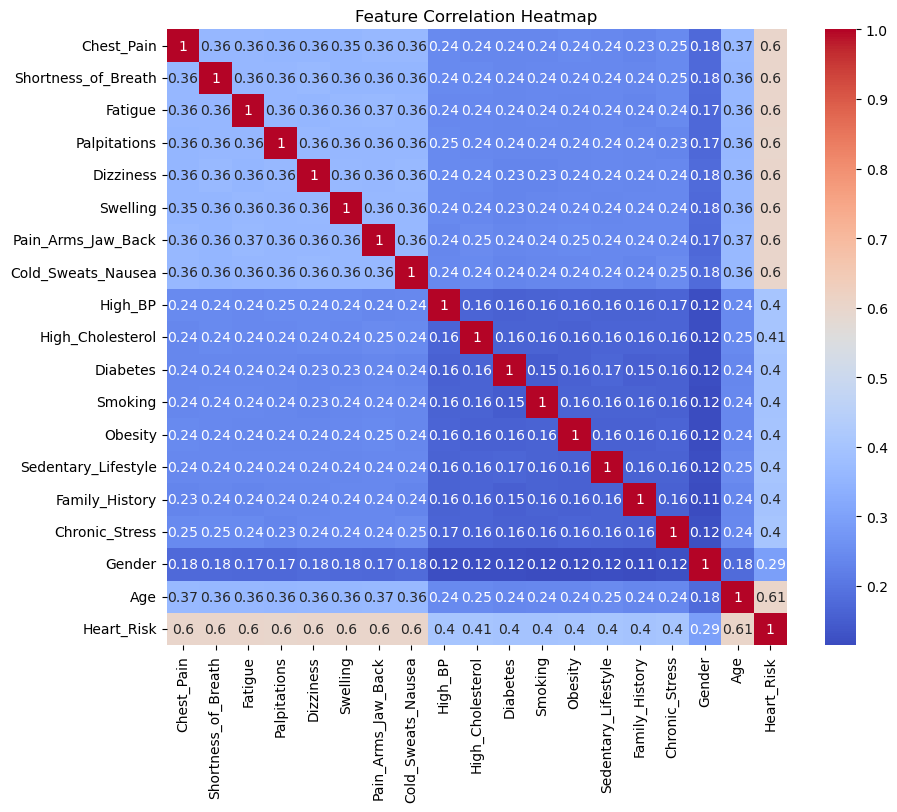

In [3]:
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title("Feature Correlation Heatmap")
plt.show()

In [4]:
df = df.dropna()

target_column = "Heart_Risk"

X = df.drop(columns=[target_column])
y = df[target_column]

# Add slight noise (keeps realistic accuracy)
X = X + np.random.normal(0, 0.2, X.shape)

training_columns = X.columns.tolist()

In [5]:
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.25, random_state=42, stratify=y_temp
)

print("Train:", X_train.shape)
print("Validation:", X_val.shape)
print("Test:", X_test.shape)

Train: (42000, 18)
Validation: (14000, 18)
Test: (14000, 18)


In [6]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

In [7]:
accuracy_scores = []
error_rates = []
k_values = range(20, 50)

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k, weights='uniform')
    knn.fit(X_train_scaled, y_train)

    val_pred = knn.predict(X_val_scaled)

    accuracy_scores.append(accuracy_score(y_val, val_pred))
    error_rates.append(np.mean(val_pred != y_val))

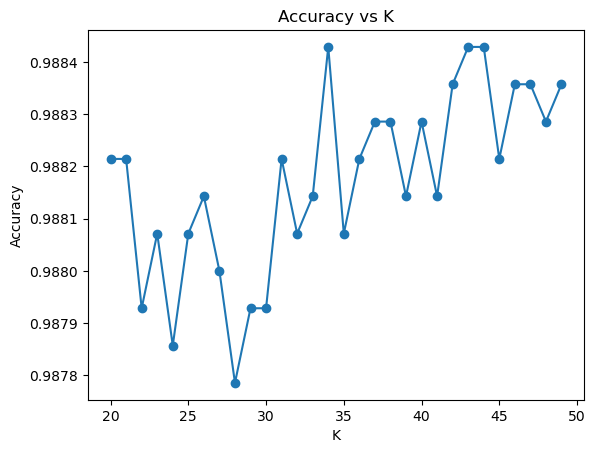

In [8]:
plt.figure()
plt.plot(k_values, accuracy_scores, marker='o')
plt.title("Accuracy vs K")
plt.xlabel("K")
plt.ylabel("Accuracy")
plt.show()

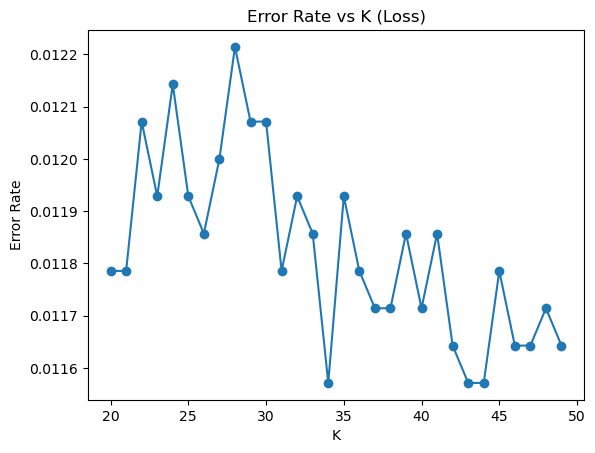

In [9]:
plt.figure()
plt.plot(k_values, error_rates, marker='o')
plt.title("Error Rate vs K (Loss)")
plt.xlabel("K")
plt.ylabel("Error Rate")
plt.show()

In [10]:
best_k = accuracy_scores.index(max(accuracy_scores)) + 20
print("Best K:", best_k)

model = KNeighborsClassifier(n_neighbors=best_k, weights='uniform')
model.fit(X_train_scaled, y_train)

Best K: 34


KNeighborsClassifier(n_neighbors=34)

In [11]:
train_acc = accuracy_score(y_train, model.predict(X_train_scaled))
val_acc = accuracy_score(y_val, model.predict(X_val_scaled))

test_pred = model.predict(X_test_scaled)
test_acc = accuracy_score(y_test, test_pred)

precision = precision_score(y_test, test_pred)
recall = recall_score(y_test, test_pred)
f1 = f1_score(y_test, test_pred)

print("\n===== RESULTS =====")
print(f"Training Accuracy   : {train_acc:.4f}")
print(f"Validation Accuracy : {val_acc:.4f}")
print(f"Test Accuracy       : {test_acc:.4f}")
print(f"Precision           : {precision:.4f}")
print(f"Recall              : {recall:.4f}")
print(f"F1 Score            : {f1:.4f}")

print("\nClassification Report:\n")
print(classification_report(y_test, test_pred))


===== RESULTS =====
Training Accuracy   : 0.9885
Validation Accuracy : 0.9884
Test Accuracy       : 0.9877
Precision           : 0.9870
Recall              : 0.9884
F1 Score            : 0.9877

Classification Report:

              precision    recall  f1-score   support

         0.0       0.99      0.99      0.99      7000
         1.0       0.99      0.99      0.99      7000

    accuracy                           0.99     14000
   macro avg       0.99      0.99      0.99     14000
weighted avg       0.99      0.99      0.99     14000



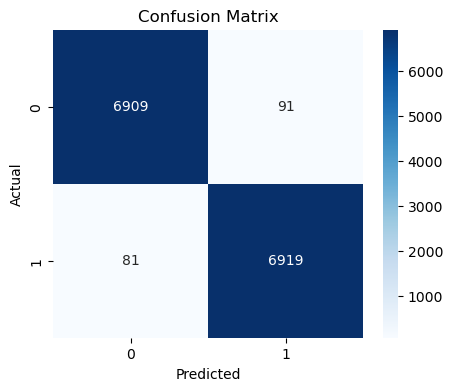

In [12]:
cm = confusion_matrix(y_test, test_pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [13]:
model_path = r"D:\SLIIT UNI\Y4S2\ML\assignment 01\dataset\save_model_2\knn_model.pkl"
scaler_path = r"D:\SLIIT UNI\Y4S2\ML\assignment 01\dataset\save_model_2\scaler_knn.pkl"
columns_path = r"D:\SLIIT UNI\Y4S2\ML\assignment 01\dataset\save_model_2\columns_knn.pkl"

joblib.dump(model, model_path)
joblib.dump(scaler, scaler_path)
joblib.dump(training_columns, columns_path)

print("Model saved successfully!")

Model saved successfully!


In [14]:
manual_input = {
    'Chest_Pain': 1,
    'Shortness_of_Breath': 1,
    'Fatigue': 0,
    'Palpitations': 0,
    'Dizziness': 0,
    'Swelling': 0,
    'Pain_Arms_Jaw_Back': 1,
    'Cold_Sweats_Nausea': 0,
    'High_BP': 1,
    'High_Cholesterol': 1,
    'Diabetes': 0,
    'Smoking': 1,
    'Obesity': 0,
    'Sedentary_Lifestyle': 1,
    'Family_History': 1,
    'Chronic_Stress': 1,
    'Gender': 1,
    'Age': 55
}

input_df = pd.DataFrame([manual_input])
input_df = input_df[training_columns]

input_scaled = scaler.transform(input_df)

prediction = model.predict(input_scaled)[0]
probability = model.predict_proba(input_scaled)[0][1]

print("\n===== MANUAL TEST =====")
print("Prediction:", "Heart Disease" if prediction == 1 else "No Heart Disease")
print(f"Probability: {probability:.4f}")


===== MANUAL TEST =====
Prediction: Heart Disease
Probability: 0.7059
